In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors
import matplotlib.gridspec as gridspec
from scipy import stats
import pyvinecopulib as pv
from scipy.stats import rankdata
import os

## Data import

### Discharge

Processing data/Mill1.csv...
Success! Merged data from 1985-01-01 to 2000-01-01


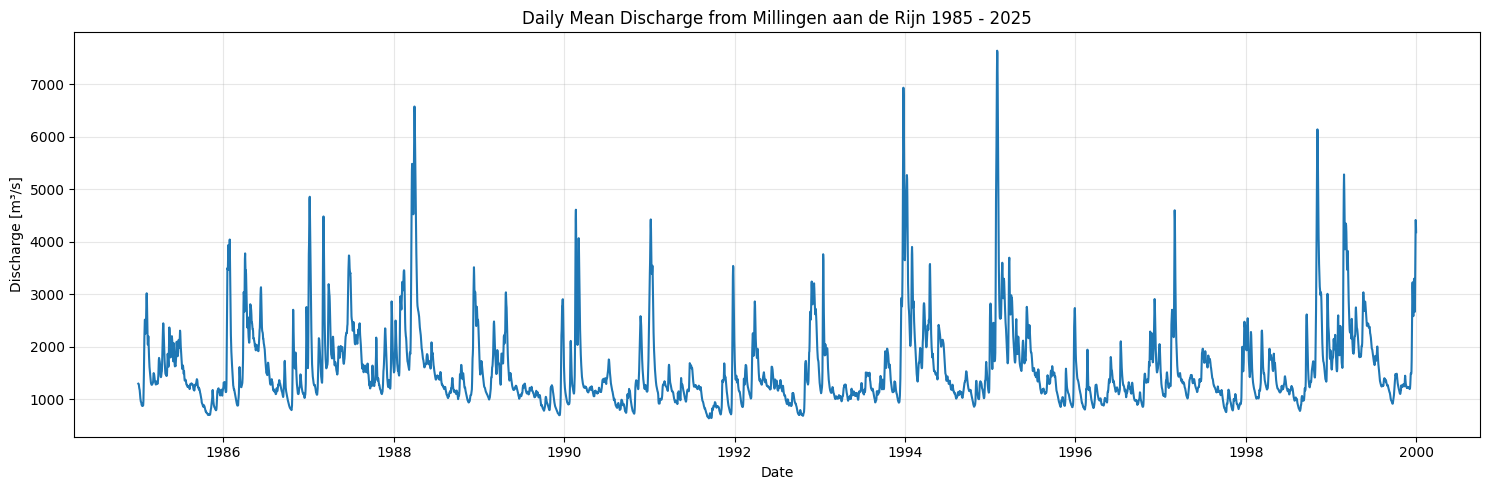

In [2]:
files = ['data/Mill1.csv', 'data/Mill2.csv', 'data/Mill3.csv', 'data/Mill4.csv']

df_discharge = []

for file_name in files:
    # Check if file exists to prevent errors
    if os.path.exists(file_name):
        print(f"Processing {file_name}...")
        
        # Load the data
        df = pd.read_csv(file_name, sep=';', encoding="latin1")
        
        # --- Apply the exact same cleaning steps ---
        df["datum"] = pd.to_datetime(df["datum"], dayfirst=True)
        df["waarde"] = pd.to_numeric(df["waarde"].astype(str).str.replace(",", "."))
        df.loc[df["waarde"] > 1e5, "waarde"] = np.nan # remove outliers
        df = df.dropna(subset=["datum", "waarde"]) # drop rows with NaN
        
        # Calculate daily mean for this specific file
        daily_part = df.groupby("datum")["waarde"].mean()
        
        # Add to our list
        df_discharge.append(daily_part)
    else:
        print(f"Warning: {file_name} could not be found.")

# 2. Merge (concatenate) them into one single Series/DataFrame
if df_discharge:
    # Concatenate all parts and sort by date to ensure they are in order
    combined_daily = pd.concat(df_discharge).sort_index()
    
    # Optional: If there are overlapping dates between files, group by date again to average them
    # combined_daily = combined_daily.groupby(combined_daily.index).mean()

    print(f"Success! Merged data from {combined_daily.index.min().date()} to {combined_daily.index.max().date()}")

    # 3. Plot the combined result
    plt.figure(figsize=(15, 5))
    plt.plot(combined_daily.index, combined_daily.values)
    plt.xlabel("Date")
    plt.ylabel("Discharge [m³/s]")
    plt.title("Daily Mean Discharge from Millingen aan de Rijn 1985 - 2025")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data was loaded.")


### Water level

In [3]:
filename = 'data/nijmegen_haven_2022-2024.csv'
df_waterlevel = pd.read_csv(filename, sep=';', encoding="latin1")
df_waterlevel["datum"] = pd.to_datetime(df_waterlevel["WAARNEMINGDATUM"],dayfirst=True)
df_waterlevel["waarde"] = pd.to_numeric(df_waterlevel["NUMERIEKEWAARDE"].astype(str).str.replace(",", "."))
df_waterlevel.loc[df_waterlevel["waarde"] > 1e5, "waarde"] = np.nan # remove outliers
df_waterlevel = df_waterlevel.dropna(subset=["datum", "waarde"]) # drop rows with NaN in 'datum' or 'waarde'
daily = df_waterlevel.groupby("datum")["waarde"].mean() # transform to daily mean 

plt.figure(figsize=(15, 5))
plt.plot(daily.index, daily.values)
plt.xlabel("Date")
plt.ylabel("Waterlevel [cm]")
plt.title(f"Daily waterlevel values from Nijmegen Haven 2022-2024")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'data/nijmegen_haven_2022-2024.csv'

### Temperature alps

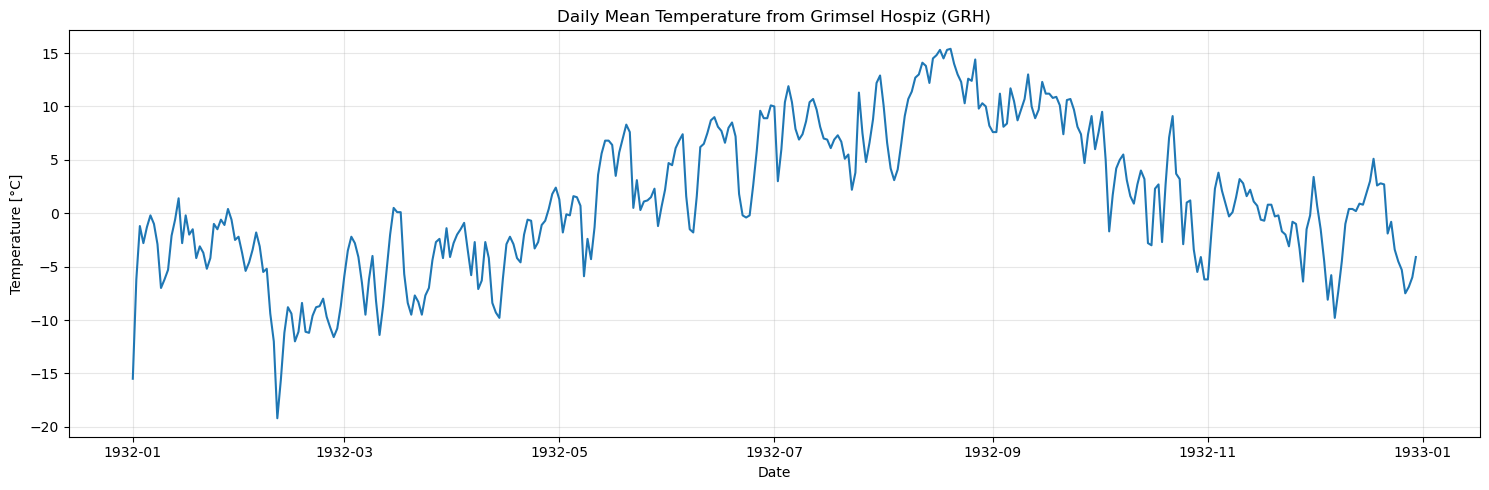

In [ ]:
file_name = 'data/ogd-nbcn_grh_d_historical.csv' 

df_temperature = pd.read_csv(file_name, sep=';', encoding="latin1")
df_temperature["datum"] = pd.to_datetime(df_temperature["reference_timestamp"], dayfirst=True)


df_temperature["temperature"] = pd.to_numeric(
    df_temperature["ths200d0"].astype(str).str.replace(",", "."), errors='coerce'
)

df_temperature = df_temperature.dropna(subset=["datum", "temperature"])

# 2. Fix: Grouping is unnecessary. Set the 'datum' as the index for time series plotting.
df_temperature = df_temperature.set_index("datum").sort_index()

one_yeardaily = df_temperature[:365]

# 3. Plotting
plt.figure(figsize=(15, 5))

# Plot the index (Date) vs the temperature column values
plt.plot(one_yeardaily.index, one_yeardaily["temperature"].values)

# 4. Fix: Correcting the Y-axis label from "Discharge" to "Temperature"
plt.xlabel("Date")
plt.ylabel("Temperature [°C]")
plt.title(f"Daily Mean Temperature from Grimsel Hospiz (GRH)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Precipitation

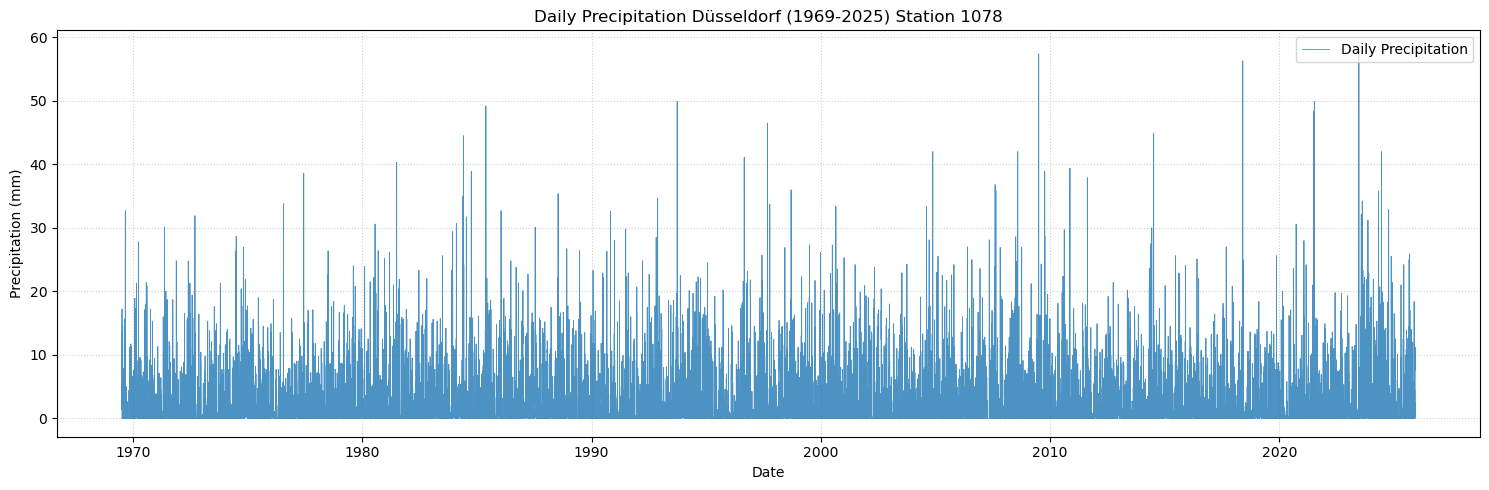

In [ ]:
file_name = 'data/dusseldorf_precipitation.csv'

# Column names to look for (based on your CSV header)
date_col_name = 'Zeitstempel'
value_col_name = 'Wert'
# --- End Configuration ---

# 1. Read file as raw text lines
# This approach is chosen because the CSV has a complex quoting format 
# (double quotes around lines AND values) which confuses the standard pandas parser.
with open(file_name, 'r') as f:
    lines = f.readlines()

# 2. Parse data manually
data = []
for line in lines:
    line = line.strip()
    
    # Remove outer quotes if present
    if line.startswith('"'): line = line[1:]
    if line.endswith('"'): line = line[:-1]
    
    # Clean up inner quotes (DWD format often uses "" as escape or separator)
    # We replace double quotes with nothing, and single quotes with nothing
    # Then split by comma.
    clean_line = line.replace('""', '').replace('"', '')
    
    # Split the line into columns
    parts = clean_line.split(',')
    
    # Remove empty strings that might appear at the end (due to trailing commas)
    parts = [p for p in parts if p.strip() != '']
    
    data.append(parts)

# 3. Create DataFrame
# The first row contains headers
if not data:
    raise ValueError("File appears to be empty.")
    
header = [h.strip() for h in data[0]]
rows = data[1:]

df = pd.DataFrame(rows, columns=header)

# 4. Validate and Find Columns
# Sometimes column names have extra spaces, so we search for them flexibly
if date_col_name not in df.columns:
    found = False
    for col in df.columns:
        if date_col_name in col:
            date_col_name = col
            found = True
            break
    if not found:
        raise ValueError(f"Column '{date_col_name}' not found. Available: {df.columns}")

if value_col_name not in df.columns:
    for col in df.columns:
        if value_col_name in col:
            value_col_name = col
            break

# 5. Data Conversion and Cleaning
# Convert date string to datetime objects
df[date_col_name] = pd.to_datetime(df[date_col_name], format='%Y-%m-%d', errors='coerce')

# Convert values to numeric (floats)
df[value_col_name] = pd.to_numeric(df[value_col_name], errors='coerce')

# Drop rows where date or value conversion failed
df.dropna(subset=[date_col_name, value_col_name], inplace=True)

# Set date as index
df.set_index(date_col_name, inplace=True)

# Filter out invalid negative values
df = df[df[value_col_name] >= 0]

# Ensure the timeline is continuous
# CHANGE: Assign to specific variable 'df_precipitation' instead of generic 'df'
df_precipitation = df.asfreq('D', fill_value=0.0)

# 6. Plotting Daily Data
plt.figure(figsize=(15, 5))

# Plot daily values
plt.plot(df.index, df[value_col_name], 
         label='Daily Precipitation', 
         color='#1f77b4',  # Standard matplotlib blue
         linewidth=0.6,    # Thinner line for dense daily data
         alpha=0.8)        # Slight transparency

# Setup titles and labels
start_year = df.index.min().year
end_year = df.index.max().year

plt.title(f'Daily Precipitation Düsseldorf ({start_year}-{end_year}) Station 1078')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')

# Add a legend and grid
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Optional: Set Y-axis limit if outliers make the plot unreadable
# plt.ylim(0, 100) 

plt.tight_layout()

# # 7. Save and Show
# output_filename = 'dusseldorf_precipitation_daily.png'
# plt.savefig(output_filename, dpi=150)
# print(f"Success! Plot saved as: {output_filename}")
plt.show()

### Groundwater level

In [ ]:
df_gw = pd.read_csv('data/groundwater.csv', delimiter=';') # Rename to df_gw
df_gw['meetwaarde (m NAP)'] = df_gw['meetwaarde (m NAP)'] / 100
df_gw['date'] = pd.to_datetime(df_gw['datum'] + ' ' + df_gw['tijd'], dayfirst=True)
df_gw = df_gw.set_index('date')
df_gw = df_gw.drop(columns=['datum', 'tijd'])
df_gw = df_gw.resample('D').mean()



### Combine Dataframes

Processing variables...
Combining data...
Shape before dropna: (34311, 4)
Success! Final shape: (3923, 4)
Period: 2013-01-01 to 2024-01-23
            Discharge_m3s  Temperature_C  Precipitation_mm  Groundwater_m
2013-01-01    4191.446493           -5.8               5.0       6.879375
2013-01-02    3887.455644          -11.3               0.5       6.883000
2013-01-03    3536.374827           -7.4               1.3       6.881125
2013-01-04    3183.239792           -1.1               2.1       6.872875
2013-01-05    2874.311581           -2.8               0.1       6.868875


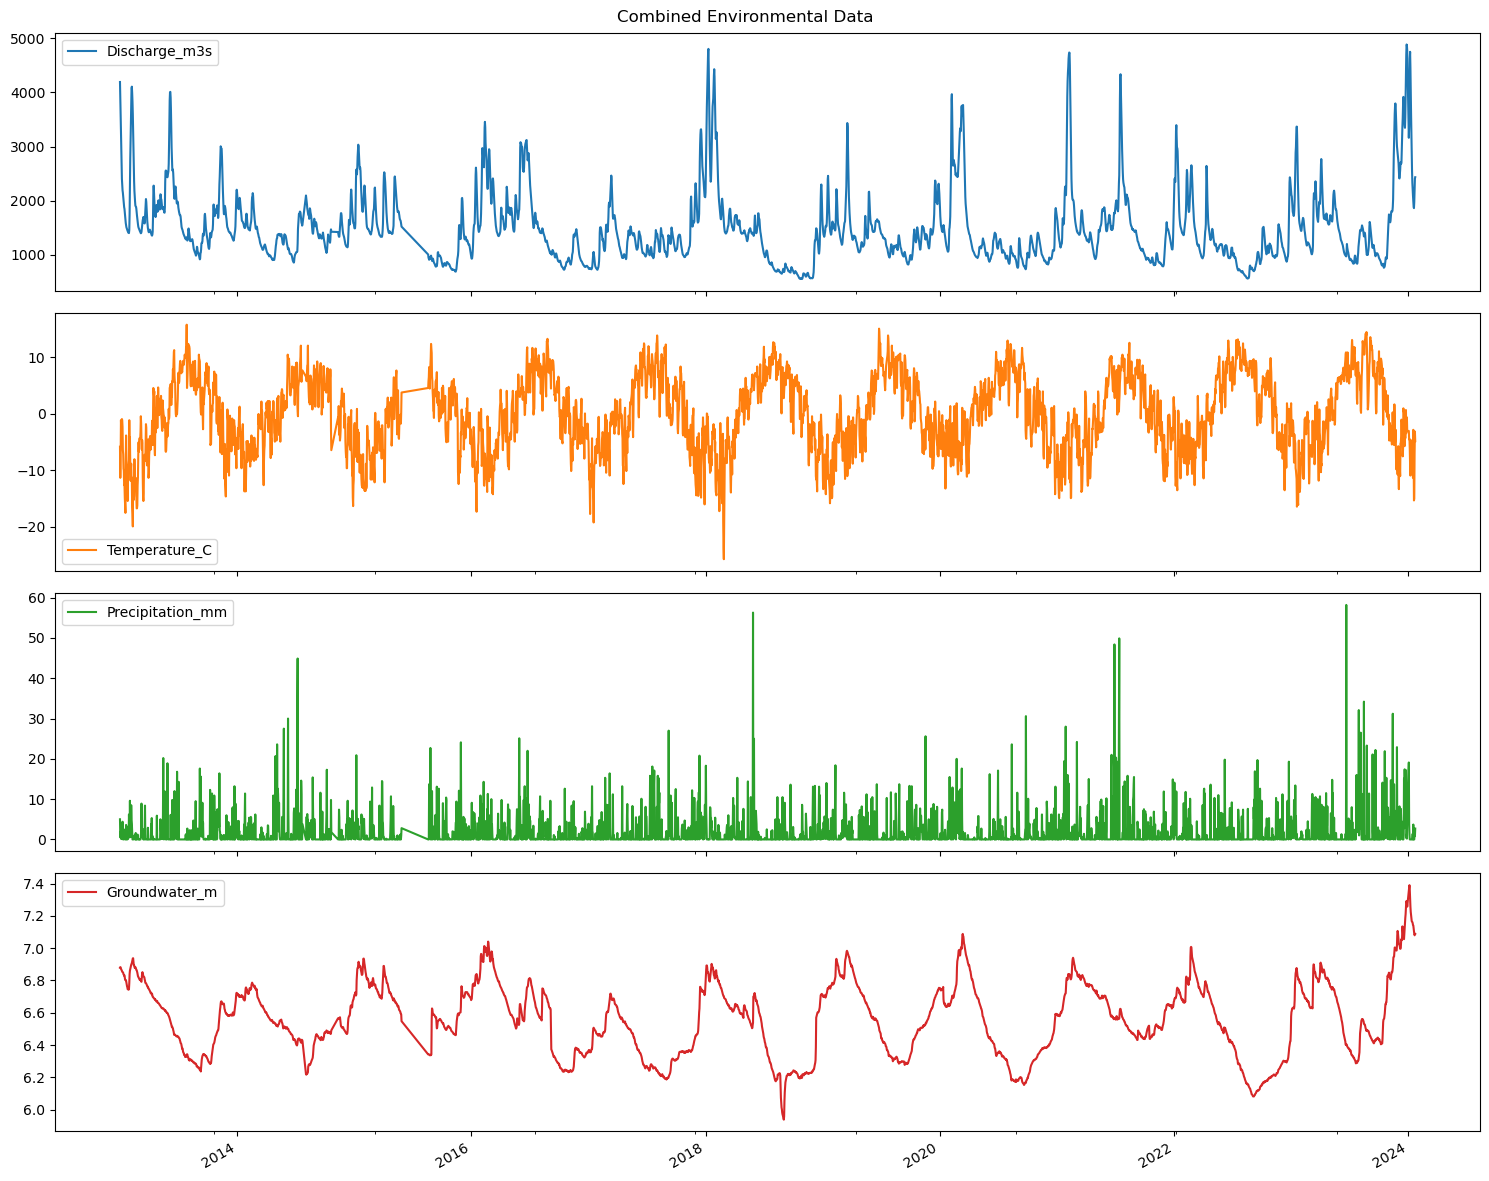

In [ ]:
# --- 1. HELPER FUNCTION (Fixed for TypeError) ---
def get_clean_series(data, new_name):
    """
    Takes a DataFrame, Series, or List and returns a clean, named Series.
    Handles grouping duplicates automatically.
    """
    # Handle List (if it's a list of parts, e.g. discharge)
    if isinstance(data, list):
        data = pd.concat(data)

    # Handle Duplicates (Group by Date)
    # FIX: numeric_only=True prevents crashing on text columns in newer Pandas versions
    grouped = data.groupby(level=0).mean(numeric_only=True)
    
    # Extract Values
    if isinstance(grouped, pd.DataFrame):
        # Verify we have numeric columns left
        if grouped.shape[1] > 0:
            s = grouped.iloc[:, 0]
        else:
            # Fallback for empty or non-numeric frames
            return pd.Series(name=new_name, dtype='float64')
    else:
        s = grouped
        
    return s.rename(new_name)


# --- 2. RELOAD PRECIPITATION (Düsseldorf) ---
# Ensure this is assigned to 'df_precipitation' specifically
file_name_precip = 'data/dusseldorf_precipitation.csv'

# (Your specific parsing logic for the complex CSV format)
with open(file_name_precip, 'r') as f:
    lines = f.readlines()

data = []
for line in lines:
    clean_line = line.strip().replace('""', '').replace('"', '') # Clean quotes
    parts = clean_line.split(',')
    parts = [p for p in parts if p.strip() != '']
    data.append(parts)

if len(data) > 1:
    header = [h.strip() for h in data[0]]
    df_precip_raw = pd.DataFrame(data[1:], columns=header)
    
    # Dynamic column finding
    date_col = next((c for c in df_precip_raw.columns if 'Zeitstempel' in c), None)
    val_col = next((c for c in df_precip_raw.columns if 'Wert' in c), None)
    
    if date_col and val_col:
        df_precip_raw[date_col] = pd.to_datetime(df_precip_raw[date_col], format='%Y-%m-%d', errors='coerce')
        df_precip_raw[val_col] = pd.to_numeric(df_precip_raw[val_col], errors='coerce')
        df_precip_raw.dropna(subset=[date_col, val_col], inplace=True)
        df_precip_raw.set_index(date_col, inplace=True)
        
        # Save to specific variable
        df_precipitation = df_precip_raw.asfreq('D', fill_value=0.0)
    else:
        print("Error: Could not find precipitation columns.")
        df_precipitation = pd.DataFrame() # Empty fallback


# --- 3. RELOAD GROUNDWATER ---
# Ensure this is assigned to 'df_groundwater' specifically
df_gw = pd.read_csv('data/groundwater.csv', delimiter=';')

# Clean values (replace comma with dot if string, handle division)
# We coerce errors to NaN to avoid crashes on text
df_gw['meetwaarde (m NAP)'] = pd.to_numeric(
    df_gw['meetwaarde (m NAP)'].astype(str).str.replace(',', '.'), errors='coerce'
) / 100

df_gw['date'] = pd.to_datetime(df_gw['datum'] + ' ' + df_gw['tijd'], dayfirst=True)
df_gw = df_gw.set_index('date')
df_gw = df_gw.drop(columns=['datum', 'tijd'])

# Save to specific variable
df_groundwater = df_gw.resample('D').mean()


# --- 4. MERGE EVERYTHING ---

print("Processing variables...")

# Process each variable safely using the fixed helper
# Note: df_discharge (list) and df_temperature (DataFrame) must exist from previous cells
s_discharge = get_clean_series(df_discharge, "Discharge_m3s")
s_temp      = get_clean_series(df_temperature, "Temperature_C")
s_precip    = get_clean_series(df_precipitation, "Precipitation_mm")
s_ground    = get_clean_series(df_groundwater, "Groundwater_m")

print("Combining data...")
# Concatenate all 4 series
df_analysis = pd.concat([s_discharge, s_temp, s_precip, s_ground], axis=1)

# Sort by date
df_analysis = df_analysis.sort_index()

print(f"Shape before dropna: {df_analysis.shape}")

# Filter: Only keep rows where ALL 4 variables have data
# (If dates don't overlap, this will result in empty data)
df_final = df_analysis.dropna()

print(f"Success! Final shape: {df_final.shape}")

if not df_final.empty:
    print(f"Period: {df_final.index.min().date()} to {df_final.index.max().date()}")
    print(df_final.head())
    
    # Plotting to verify
    df_final.plot(subplots=True, figsize=(15, 12), title="Combined Environmental Data")
    plt.tight_layout()
    plt.show()
else:
    print("\nWarning: The intersection resulted in an empty DataFrame.")
    print("This means there are no days where ALL 4 datasets have data simultaneously.")
    print("Check your date ranges below:")
    print(f"Discharge Range:   {s_discharge.index.min()} to {s_discharge.index.max()}")
    print(f"Temperature Range: {s_temp.index.min()} to {s_temp.index.max()}")
    print(f"Precipitation Range: {s_precip.index.min()} to {s_precip.index.max()}")
    print(f"Groundwater Range:   {s_ground.index.min()} to {s_ground.index.max()}")

## NPBN Analysis

### No Time Lag

In [ ]:
names = list(df_final.columns)
print(names)

N = df_final.shape[1] # number of nodes
parents1 = [None]*N  # create an empty list 

parents1[0] = []          
parents1[1] = [0]            
parents1[2] = [0]      
parents1[3] = [0]    

['Discharge_m3s', 'Temperature_C', 'Precipitation_mm', 'Groundwater_m']


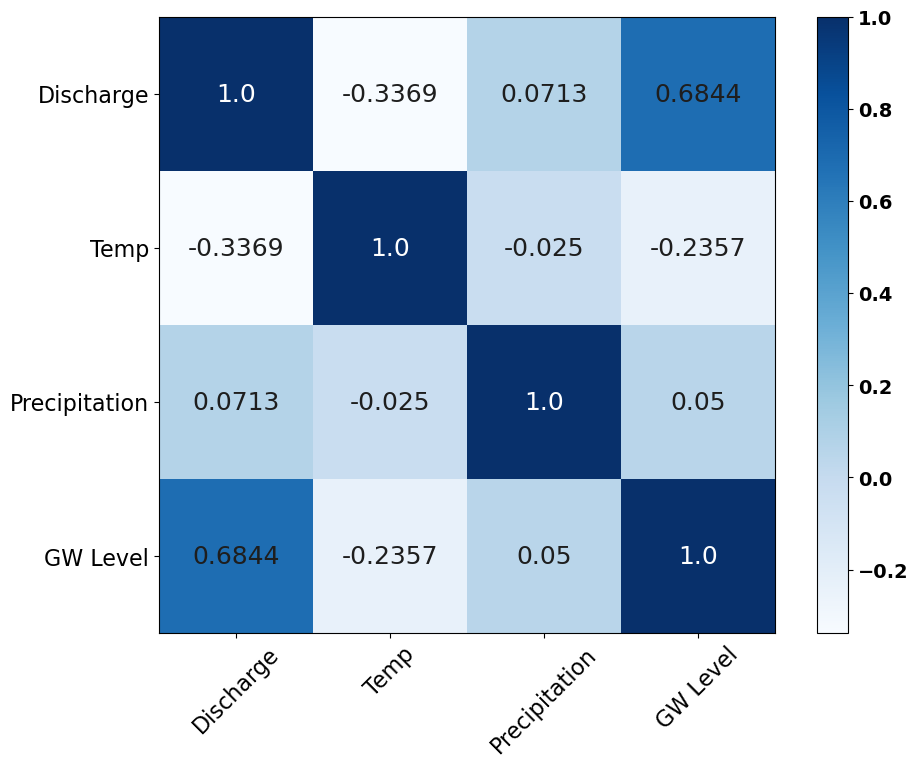

In [ ]:
from py_banshee.rankcorr import bn_rankcorr

R_BN_1 = bn_rankcorr(parents1, df_final, var_names=['Discharge', 'Temp', 'Precipitation', 'GW Level'], is_data=True, plot=True)

# Lag (calculated)


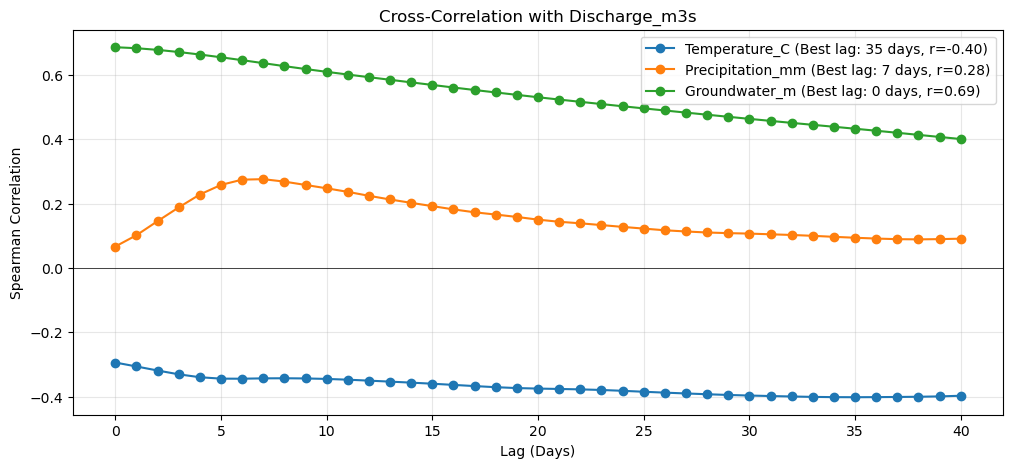

Optimal Shifts Found:
 - Temperature_C: 35 days
 - Precipitation_mm: 7 days
 - Groundwater_m: 0 days


In [ ]:
def analyze_lag(df, target, parent, max_lag=40):
    lags = range(max_lag + 1)
    correlations = []
    
    for lag in lags:
        # Shift parent data "down" by lag days
        # This aligns Parent(t-lag) with Target(t)
        shifted_parent = df[parent].shift(lag)
        
        # Calculate Spearman correlation (robust to non-linearities)
        corr = df[target].corr(shifted_parent, method='spearman')
        correlations.append(corr)
        
    # Find best lag
    # We look for the maximum ABSOLUTE correlation (magnitude)
    abs_corrs = [abs(c) for c in correlations]
    best_lag = abs_corrs.index(max(abs_corrs))
    best_corr = correlations[best_lag]
    
    return lags, correlations, best_lag, best_corr

# Configuration
target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Precipitation_mm', 'Groundwater_m']

# Run Analysis
plt.figure(figsize=(12, 5))

best_lags = {}

for parent in parents:
    lags, corrs, best_k, max_r = analyze_lag(df_analysis, target_var, parent)
    best_lags[parent] = best_k
    
    # Plot
    plt.plot(lags, corrs, marker='o', label=f'{parent} (Best lag: {best_k} days, r={max_r:.2f})')

plt.title(f'Cross-Correlation with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('Spearman Correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

Shifted Temperature_C by 35 days.
Shifted Precipitation_mm by 7 days.
Groundwater_m kept at lag 0.


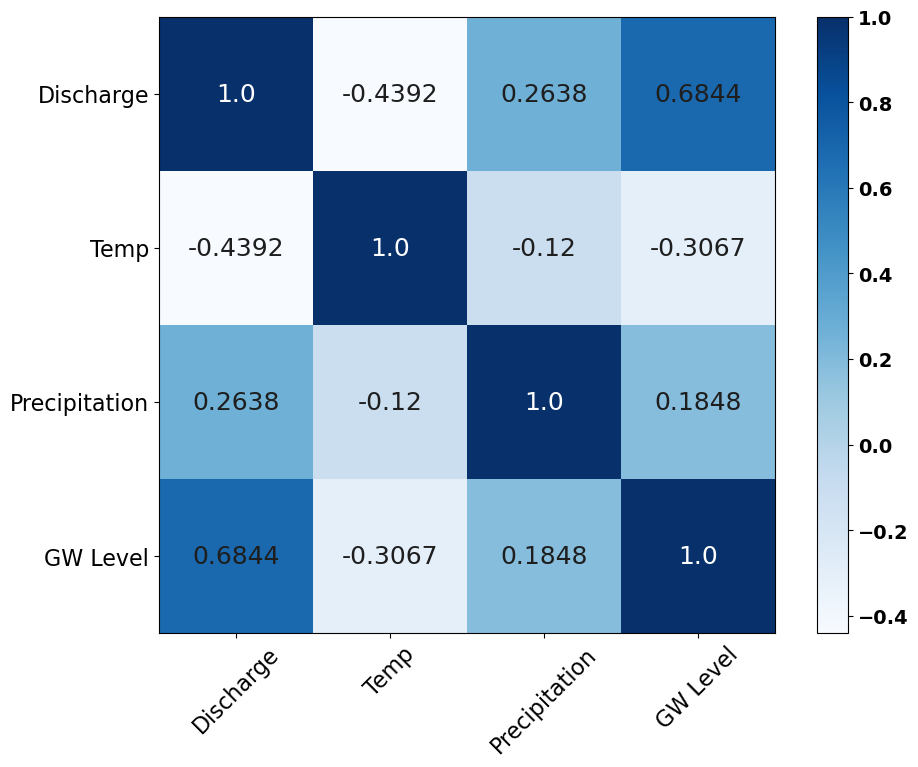

In [ ]:
# Create a copy to avoid messing up the original
df_shifted = df_analysis.copy()

# Apply the shifts automatically based on the analysis above
for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        # Shift the column and rename it to indicate it's lagged
        df_shifted[col] = df_shifted[col].shift(lag)
        print(f"Shifted {col} by {lag} days.")
    else:
        print(f"{col} kept at lag 0.")

# Shifting creates empty rows at the start (NaNs), so we drop them
df_shifted = df_shifted.dropna()

# # Check the new correlation matrix
# plt.figure(figsize=(6, 5))
# sns.heatmap(df_shifted.corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# plt.title("Correlation Matrix (Time-Shifted)")
# plt.show()
R_BN_1 = bn_rankcorr(parents1, df_shifted, var_names=['Discharge', 'Temp', 'Precipitation', 'GW Level'], is_data=True, plot=True)

### Shifted (fixed)

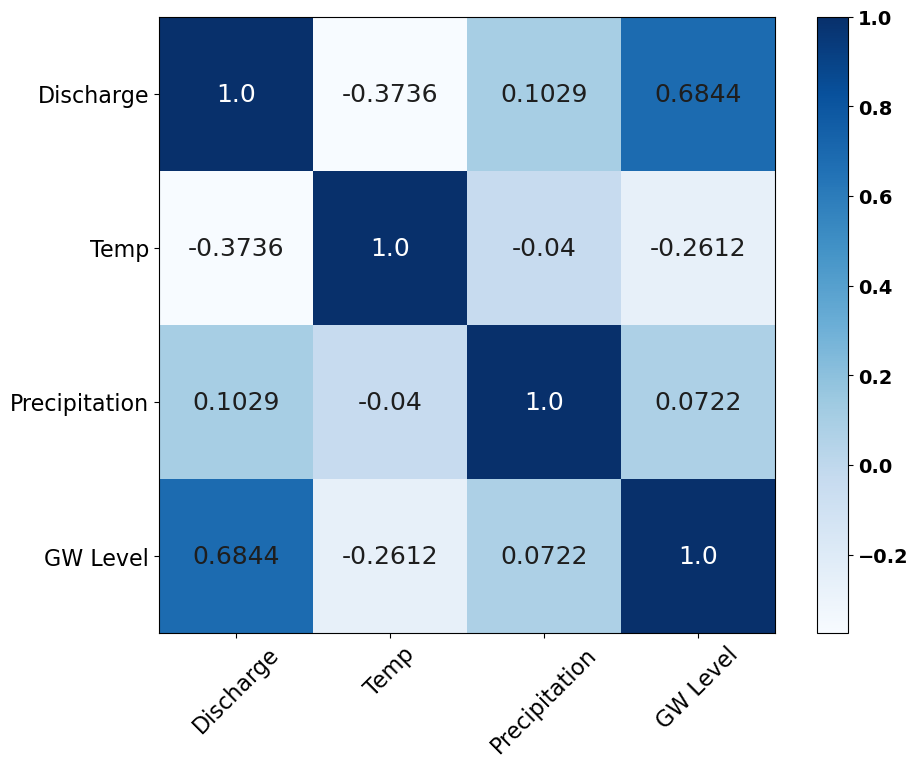

In [ ]:
best_lags = {
    'Temperature_C': 6,       # Switzerland (Long travel)
    'Precipitation_mm': 1,
    'Groundwater_m': 0     # Dusseldorf (Short travel)
}

# Apply these specific shifts
df_shifted_fixed = df_analysis.copy()
for col, lag in best_lags.items():
    df_shifted_fixed[col] = df_shifted_fixed[col].shift(lag)

df_shifted_fixed = df_shifted_fixed.dropna()

R_BN_1 = bn_rankcorr(parents1, df_shifted_fixed, var_names=['Discharge', 'Temp', 'Precipitation', 'GW Level'], is_data=True, plot=True)